Create simple plots of the deformation and the homogenized quantities over the course of a trajectory, and then create the various plots shown in the paper.

# Check contents of dicts

In [13]:
import pickle
from pathlib import Path

path = Path('data/dataset1/final_dataset')
pkl_files = sorted(p for p in path.rglob('*.pkl') if not p.name.startswith('rngstate'))
print(f'Found {len(pkl_files)} pickle file(s)')

for file in pkl_files:
    print(f'\n{file}')
    with file.open('rb') as f:
        data = pickle.load(f)

    for key, value in data.items():
        shape = getattr(value, 'shape', '')
        print(key, type(value).__name__, shape)
        if isinstance(value, dict):
            for key2, value2 in value.items():
                shape2 = getattr(value2, 'shape', '')
                print('\t', key2, type(value2).__name__, shape2)

    break

if not pkl_files:
    print(f'No .pkl files found under {path.resolve()}')

Found 2 pickle file(s)

data\dataset1\final_dataset\p1_square_2026-06-07_13-35-43.685618\p1_square_2026-06-07_13-35-43.685618_00.pkl
uc dict 
	 transforms list 
	 corners_per_fd list 
	 n_fds int 
	 bounds_per_fd list 
	 bound_inds_per_fd list 
	 lattice vectors ndarray (2, 2)
	 corners ndarray (4, 2)
	 points ndarray (7, 2)
	 points_inds_per_fd ndarray (1, 7)
	 edges ndarray (5, 2)
	 fd_of_points ndarray (7,)
	 bounds list 
	 bound_inds list 
	 bound_inds_flat list 
	 linked_bounds list 
	 n_corners int 
	 linked_corners list 
	 equiv_nodes list 
	 corner_inds list 
	 corner_inds_flat list 
	 periodic_edges ndarray (0,)
	 n_points int 
	 edges_directional ndarray (10, 2)
	 periodic_nodes list 
	 bound_per_node list 
	 fds_per_point list 
	 edge_fds list 
	 proto_edges ndarray (10, 2)
	 n_edges_d int 
	 proto_inds ndarray (10,)
fd dict 
	 group str 
	 shape str 
	 a float64 ()
	 b float64 ()
	 gamma float 
	 a1 ndarray (2,)
	 a2 ndarray (2,)
	 bounds list 
	 corners ndarray (4, 2)
	 li

# Plot deformation & evolution of stress components

In [14]:
import pickle
from pathlib import Path

geom = 'p1_square_2026-06-07_13-35-43.685618'
base_path = Path('data/dataset1/final_dataset')
matches = sorted(p for p in base_path.rglob(f'{geom}*.pkl') if not p.name.startswith('rngstate'))
if not matches:
    raise FileNotFoundError(f'No pickle file found for {geom} under {base_path.resolve()}')

path = next((p for p in matches if '_fd_' not in p.name), matches[0])
print(f'Loading {path}')
with path.open('rb') as f:
    data = pickle.load(f)

Loading data\dataset1\final_dataset\p1_square_2026-06-07_13-35-43.685618\p1_square_2026-06-07_13-35-43.685618_00.pkl


In [15]:

import numpy as np
import matplotlib.pyplot as plt

# Visualize generated geometry before simulation

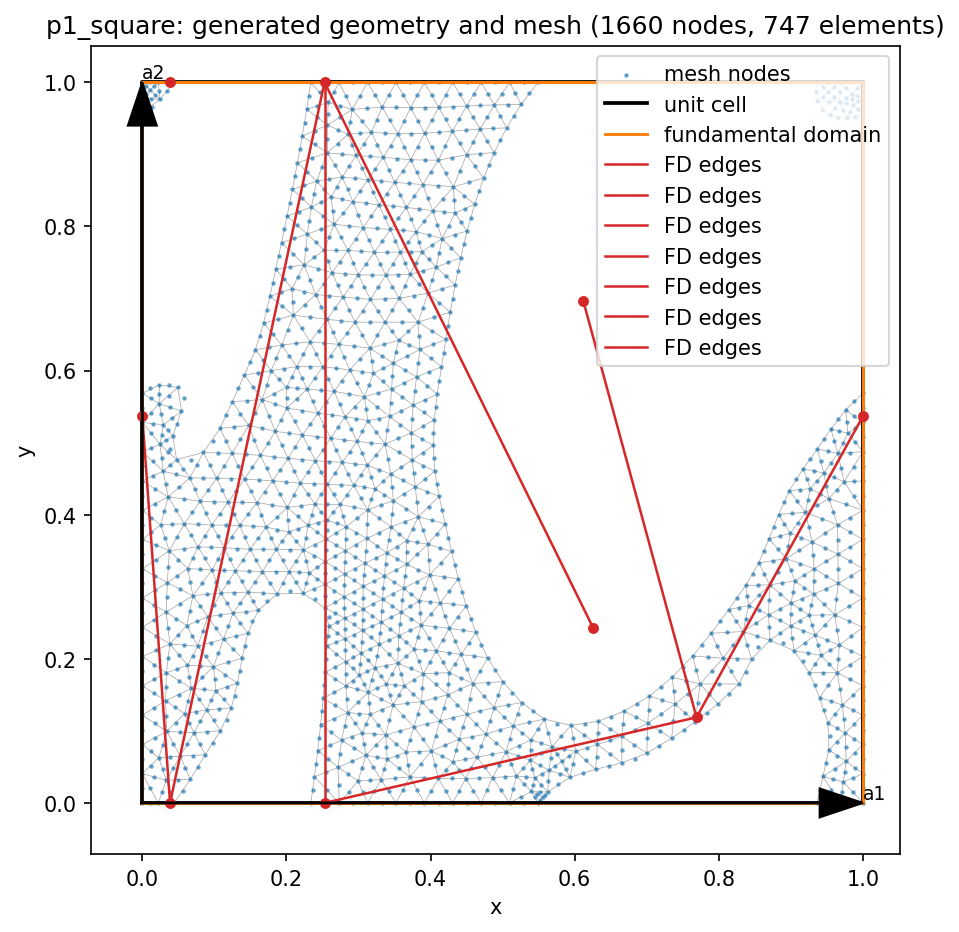

In [16]:
# This cell only uses the geometry/mesh pickle created in the first generation step.
p = data.get('p_all', data['p'])
t = data.get('t_all', data['t'])
triangles = t[:, :3] if t.shape[1] > 3 else t

fig, ax = plt.subplots(figsize=(7, 7), dpi=150)

ax.triplot(p[:, 0], p[:, 1], triangles, color='0.65', linewidth=0.35)
ax.scatter(p[:, 0], p[:, 1], s=1.5, color='tab:blue', alpha=0.55, label='mesh nodes')

uc = data.get('uc', {})
fd = data.get('fd', {})

uc_corners = uc.get('corners')
if uc_corners is not None:
    uc_closed = np.vstack([uc_corners, uc_corners[0]])
    ax.plot(uc_closed[:, 0], uc_closed[:, 1], color='black', linewidth=1.8, label='unit cell')

fd_corners = fd.get('corners')
if fd_corners is not None:
    fd_closed = np.vstack([fd_corners, fd_corners[0]])
    ax.plot(fd_closed[:, 0], fd_closed[:, 1], color='tab:orange', linewidth=1.4, label='fundamental domain')

fd_points = fd.get('points')
fd_edges = fd.get('edges')
if fd_points is not None and fd_edges is not None:
    x, y = np.transpose(fd_points[fd_edges.T], axes=[2, 0, 1])
    ax.plot(x, y, color='tab:red', linewidth=1.2, label='FD edges')
    ax.scatter(fd_points[:, 0], fd_points[:, 1], s=18, color='tab:red', zorder=5)

lv = uc.get('lattice vectors')
if lv is not None:
    for i, vec in enumerate(lv):
        ax.arrow(0, 0, vec[0], vec[1], head_width=0.04, head_length=0.06, fc='black', ec='black', length_includes_head=True, zorder=10)
        ax.text(vec[0], vec[1], f'a{i + 1}', fontsize=9, ha='left', va='bottom')

group = fd.get('group', 'unknown')
shape = fd.get('shape', 'unknown')
ax.set_title(f'{group}_{shape}: generated geometry and mesh ({len(p)} nodes, {len(triangles)} elements)')
ax.set_aspect('equal')
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.legend(loc='best')
plt.show()

In [ ]:
# plot the mesh, before and after deformation, and show the periodicity by marking the source and image nodes. Also show the lattice vectors.

p = data['mesh']['RVE']['p']  # initial node positions
e = data['mesh']['RVE']['edges']  # mesh edges
source_nodes = data['mesh']['RVE']['source_nodes']
image_nodes = data['mesh']['RVE']['image_nodes']

# find time steps belonging to trajectory 3
inds = np.where(data['time_steps']['trajectory'] == 3)[0]
# deformed position at the last time step of trajectory 3
p_def = data['time_steps']['x'][inds[-1]]

lv = data['geometry']['unit_cell']['lattice_vectors']

plt.figure()

# plot nodes in their original position
plt.scatter(*p.T, s=1, c='tab:blue', label='initial position')

# plot nodes in their deformed position
plt.scatter(*p_def.T, s=1, c='tab:orange', label='deformed position')

# plot edges of deformed mesh
x, y = np.transpose(p[e.T], axes=[2,0,1])
edges0 = plt.plot(x, y, alpha=0.5, c='tab:blue')

# plot edges of deformed mesh
x, y = np.transpose(p_def[e.T], axes=[2,0,1])
edges0 = plt.plot(x, y, alpha=0.5, c='tab:orange')

# plot the source and image nodes
plt.scatter(*p[source_nodes].T, s=10, c='tab:red', label='source nodes')
plt.scatter(*p[image_nodes].T, s=10, c='tab:green', label='image nodes')

# plot the lattice vectors
plt.arrow(0, 0, lv[0, 0], lv[0, 1], head_width=0.1, head_length=0.1, fc='k', ec='k', zorder=10, length_includes_head=True)
plt.arrow(0, 0, lv[1, 0], lv[1, 1], head_width=0.1, head_length=0.1, fc='k', ec='k', zorder=10, length_includes_head=True)

# set aspect ratio to be equal
plt.gca().set_aspect('equal')

plt.legend()

In [ ]:
# plot the evolution of the stress components during trajectory 1

inds = np.where(data['time_steps']['trajectory'] == 1)[0]
Time = data['time_steps']['Time'][inds]
F = data['simulations']['F_final'][1]
P = data['time_steps']['P'][inds]

plt.figure()
plt.title(f'At Time=1.0, F=[[{F[0,0]:.3}, {F[0,1]:.3}], [{F[1,0]:.3}, {F[1,1]:.3}]]')

plt.plot(Time, P[:, 0, 0], label='$P_{11}$', marker='o')
plt.plot(Time, P[:, 1, 1], label='$P_{22}$', marker='o')
plt.plot(Time, P[:, 0, 1], label='$P_{12}$', marker='o')
plt.plot(Time, P[:, 1, 0], label='$P_{21}$', marker='o')

# add a vertical line at each bifurcation point
t_bif = np.where(data['time_steps']['is_bifurcation_point'][inds])[0]
for t in t_bif:
    plt.axvline(Time[t], c='k', linestyle='--', label='bifurcation')

plt.legend()
plt.ylabel('P')
plt.xlabel('Time')

# Find one example of each wallpaper group + Bravais lattice
Used in the paper as examples.

In [ ]:
dest_path = r'E:\OneDrive - TU Eindhoven\Werk\paper_2'
save_dir = r'E:\OneDrive - TU Eindhoven\Werk\python\wallpaper_dataset\data\dataset1\final_dataset'

import shutil
import os
import mesh_funcs as mf

combis = []
for group in mf.wallpaper_groups:
    for shape in mf.wallpaper_groups[group]['fundamental domain parameters']:
        combis.append(f'{group}_{shape}')

print(combis)


In [ ]:
len(combis)

In [ ]:
for combi in combis:
    # find one file starting with combi
    for file in os.listdir(save_dir):
        if file.startswith(combi) and file.endswith('.png'):
            # copy the file to the destination
            shutil.copy(os.path.join(save_dir, file), os.path.join(dest_path, file))
            print(file)
            break

# 12 trajectories in one figure

In [ ]:
import numpy as np
import os
import pickle
import matplotlib.pyplot as plt

In [ ]:
geom = 'p3m1_hexagonal_2024-05-22_15-33-58.634036'

path = r'data\dataset1\final_dataset\pickle_files'

with open(os.path.join(path, geom + '.pkl'), 'rb') as f:
    data = pickle.load(f)

In [ ]:
plt.rcParams.update({
    "text.usetex": True,
    'text.latex.preamble': r'\usepackage{{amsmath}} \usepackage{{amssymb}} \usepackage{{xcolor}}',
    # 'font.size': 14
})

In [ ]:
# plot the mesh, before and after deformation, and show the periodicity by marking the source and image nodes. Also show the lattice vectors.

p = data['mesh']['RVE']['p'] # initial node positions
t = data['mesh']['RVE']['t'] # initial node positions
e = data['mesh']['RVE']['edges'] # mesh edges
hb_inds = data['mesh']['RVE']['hole_boundary_edges_inds'] # indices of the hole boundary edges

corners = data['geometry']['unit_cell']['corners'] # corners of the unit cell
lv = data['geometry']['unit_cell']['lattice_vectors']

fig, axes = plt.subplots(3,4, figsize=(12, 13), dpi=150)
axes = axes.flatten()
for traj in range(12):

    ax = axes[traj]

    # deformed position at the last time step of trajectory traj
    inds = np.where(data['simulations']['time_steps']['trajectory'] == traj)[0]
    p_def = data['simulations']['time_steps']['x'][inds[-1]]
    F_temp = data['simulations']['time_steps']['F'][inds[-1]]
    lv_def = np.dot(F_temp, lv.T).T

    # plot elements of the original mesh, 2x2 RVE
    for shifts in [[0, 0], [1, 0], [0, 1], [1, 1]]:
        p2 = p +2*shifts[0]*lv[0] +2*shifts[1]*lv[1]

        # plot hole boundary edges of deformed mesh
        x, y = np.transpose(p2[e[hb_inds].T], axes=[2,0,1])
        c='lightgrey'
        edges0 = ax.plot(x, y, c=c)

    # plot elements and hole boundaries of the deformed mesh, 2x2 RVE
    for shifts in [[0, 0], [1, 0], [0, 1], [1, 1]]:
        p_def2 = p_def +2*shifts[0]*lv_def[0] +2*shifts[1]*lv_def[1]

        c = 'darkblue'
        x, y = np.transpose(p_def2[e[hb_inds].T], axes=[2,0,1])
        edges0 = ax.plot(x, y, c=c)

    # set aspect ratio to be equal
    ax.set_aspect('equal')

    # ax.gca().set_title(f'F={F_final}')
    temp_str = r'$\textbf{\textrm{F}}=\begin{pmatrix}' + f'{F_temp[0,0]:.2}' + ' & ' + f'{F_temp[0,1]:.2}' + r'\\' + f'{F_temp[1,0]:.2}' + ' & ' + f'{F_temp[1,1]:.2}' + r'\end{pmatrix}$'
    if data['simulations']['trajectories']['error_flag'][traj]:
        temp_str = temp_str + r', error_flag!'
        # make latex textcolor red
        temp_str = r'\textcolor{red}{' + temp_str + '}'

    ax.set_title(temp_str)

# for each ax, get the current axis limits and set them to be the same
xlim = [1000, -1000]
ylim = [1000, -1000]
for ax in axes:
    xlim_temp = ax.get_xlim()
    ylim_temp = ax.get_ylim()

    xlim[0] = min(xlim[0], xlim_temp[0])
    xlim[1] = max(xlim[1], xlim_temp[1])
    ylim[0] = min(ylim[0], ylim_temp[0])
    ylim[1] = max(ylim[1], ylim_temp[1])

    print(xlim, ylim)

for ax in axes:
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    ax.set_xlabel('x')
    ax.set_ylabel('y')

fig.subplots_adjust(hspace=0.2, wspace=0.3)
# plt.savefig(geom + '_12simulations.png', dpi=300, bbox_inches='tight')
    # break


In [ ]:
data['simulations']['error_flag']

# Buckling frequency

In [ ]:
import os
import pickle
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

data_buckling = {'J_final_actual': [], 'contains_bifurcation': [], 'group': [], 'shape':[], 'volume_fraction':[]}
path = r'data\dataset1\final_dataset\pickle_files'
for file in os.listdir(path):
    if file.endswith('.pkl'):
        with open(os.path.join(path, file), 'rb') as f:
            data = pickle.load(f)

        n = 12  # nr of simulations per geometry

        data_buckling['contains_bifurcation'].extend(data['simulations']['trajectories']['contains_bifurcation'])
        data_buckling['group'].extend([data['geometry']['fundamental_domain']['group']]*n)

data_buckling

In [ ]:
df = pd.DataFrame(data_buckling)
df['contains_bifurcation'] = df['contains_bifurcation'].astype(bool)
df

In [ ]:

# Calculate the count of successful and unsuccessful cases per group
df_counts = df.groupby(['group', 'contains_bifurcation']).size().unstack(fill_value=0)

# Calculate the fraction of successful cases per group
df_counts['Total'] = df_counts.sum(axis=1)
df_counts['Success_Fraction'] = df_counts[True] / df_counts['Total']
df_counts['Failure_Fraction'] = df_counts[False] / df_counts['Total']

# Pivot the DataFrame for plotting
df_pivot = df_counts[['Success_Fraction', 'Failure_Fraction']]

# Plot the stacked bar chart
df_pivot.plot(kind='bar', stacked=True, color=['tab:blue', 'tab:orange'])

# Customize the plot
# plt.title('Fraction of Buckling Cases per Group')
plt.xlabel('Wallpaper group')
plt.ylabel('Fraction of buckling cases')
plt.legend(labels=['Buckles', 'Does not buckle'])
plt.savefig('buckling_fraction.pdf', bbox_inches='tight')
plt.show()


# Check number of time steps

In [ ]:
import os
import pickle
import matplotlib.pyplot as plt

n_time_steps = []
path = r'data\dataset1\final_dataset'
for file in os.listdir(path):
    if file.endswith('.pkl'):
        with open(os.path.join(path, file), 'rb') as f:
            data = pickle.load(f)

        n = len(data['simulations']['F_final'])  # should always be twelve
        assert n==12, f'Expected 12 simulations, but got {n}'

        for i in range(n):
            inds = np.where(data['time_steps']['trajectory'] == i)[0]
            n_time_steps.append(len(inds))

n_time_steps

In [ ]:
plt.hist(n_time_steps, bins=100)
plt.xlabel('Number of time steps')
plt.ylabel('Frequency')

In [ ]:
print(f'Mean: {np.mean(n_time_steps)}')
print(f'Median: {np.median(n_time_steps)}')
print(f'Min: {np.min(n_time_steps)}')
print(f'Max: {np.max(n_time_steps)}')
print(f'Sum: {np.sum(n_time_steps)}')